### CHOLESKY DECOMPOSITION
Generating Normal random variables with given correlation from independent Normal random variables

In [31]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn

Slope: [[-0.02069345]]
Intercept: [-0.00084204]
R²: 0.00047076015495595147
r: -0.021697007972436004
RSS: 989.8526270017645


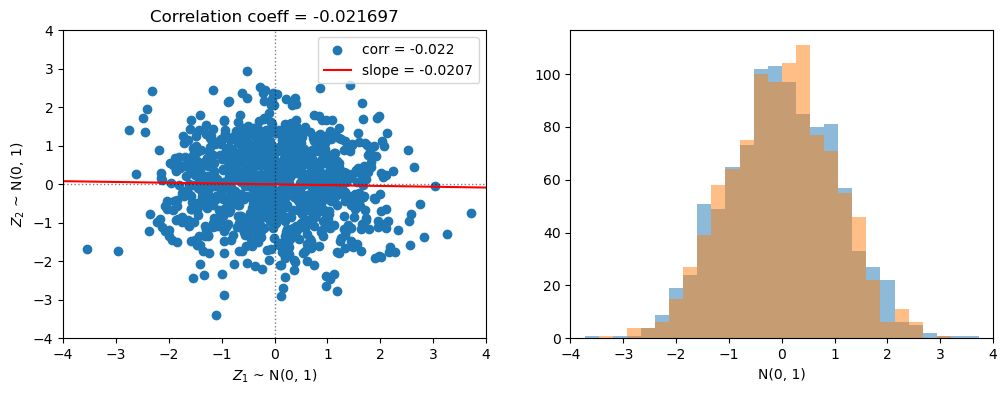

In [ ]:
# Z1 and Z2 are independent standard normal random variables
Z = np.random.normal(loc=0, scale=1, size=(2, 1000))
Z1 = Z[0,:]
Z2 = Z[1,:]


model = sklearn.linear_model.LinearRegression()
result = model.fit(Z1.reshape(-1, 1), Z2.reshape(-1, 1))
# Model parameters
slope = result.coef_
intercept = result.intercept_
# Predictions
y_pred = result.predict(Z1.reshape(-1, 1))
# Goodness-of-fit statistics
r_squared = result.score(Z1.reshape(-1, 1), Z2.reshape(-1, 1))
corr_coeff = slope[0][0] / abs(slope[0][0]) * np.sqrt(r_squared)
rss = np.sum((Z2.reshape(-1, 1) - y_pred) ** 2)
print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_squared)
print("r:", corr_coeff)
print("RSS:", rss)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].set_title(f'Correlation coeff = {round(corr_coeff, 6)}')
ax[0].scatter(Z1, Z2, label=f'corr = {round(np.corrcoef(Z1, Z2)[0, 1], 3)}')
ax[0].axvline(0, lw=1, ls=':', color='black', alpha=0.5)
ax[0].axhline(0, lw=1, ls=':', color='black', alpha=0.5)

x_line = np.linspace(-4, 4, 100)
line = intercept + x_line * slope[0][0]
ax[0].plot(x_line, line, color='red', label=f'slope = {round(slope[0][0], 4)}')

ax[0].set_xlabel(r'$Z_1$ ~ N(0, 1)')
ax[0].set_ylabel(r'$Z_2$ ~ N(0, 1)')
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].legend()

ax[1].hist(Z1, bins=30, range=(-4, 4), alpha=0.5)
ax[1].hist(Z2, bins=30, range=(-4, 4), alpha=0.5)
ax[1].set_xlabel('N(0, 1)')
ax[1].set_xlim(-4, 4)
plt.show()

In [40]:
# Let's use Cholesky decomposition to generate two random variables with a chosen correlation
rho = 0.7

corr_matrix = np.array([[1, rho],
                        [rho, 1]])

L = scipy.linalg.cholesky(corr_matrix, lower=True)

# Because we get the Lower matrix, corr_matrix = L @ L.T
# Otherwise (getting Upper) corr_matrix = U.T @ U

# We can obtain the new random variables as X = L @ Z
X = L @ Z

Slope: [[0.68522192]]
Intercept: [-0.00060133]
R²: 0.503126176655786
r: 0.709313877388414
RSS: 504.82483977089987


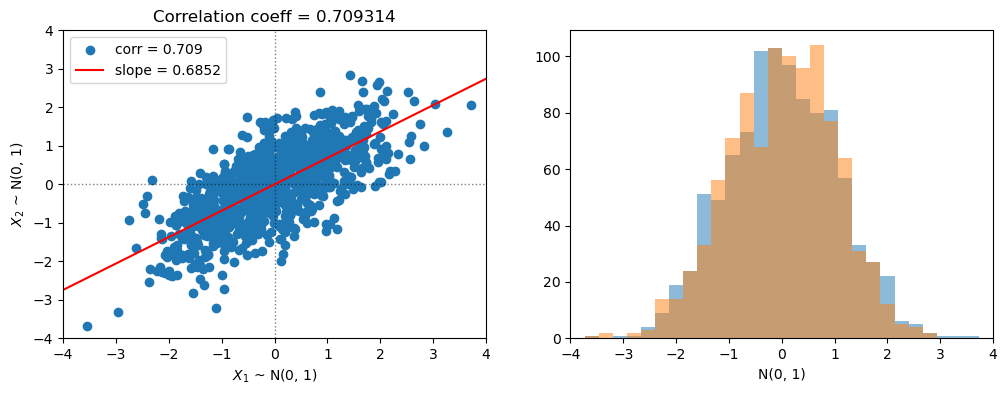

In [41]:
# X1 and X2 are standard normal random variables with predefined correlation coefficient
X1 = X[0,:]
X2 = X[1,:]


model = sklearn.linear_model.LinearRegression()
result = model.fit(X1.reshape(-1, 1), X2.reshape(-1, 1))
# Model parameters
slope = result.coef_
intercept = result.intercept_
# Predictions
y_pred = result.predict(X1.reshape(-1, 1))
# Goodness-of-fit statistics
r_squared = result.score(X1.reshape(-1, 1), X2.reshape(-1, 1))
corr_coeff = slope[0][0] / abs(slope[0][0]) * np.sqrt(r_squared)
rss = np.sum((X2.reshape(-1, 1) - y_pred) ** 2)
print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_squared)
print("r:", corr_coeff)
print("RSS:", rss)


fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].set_title(f'Correlation coeff = {round(corr_coeff, 6)}')
ax[0].scatter(X1, X2, label=f'corr = {round(np.corrcoef(X1, X2)[0, 1], 3)}')
ax[0].axvline(0, lw=1, ls=':', color='black', alpha=0.5)
ax[0].axhline(0, lw=1, ls=':', color='black', alpha=0.5)

x_line = np.linspace(-4, 4, 100)
line = intercept + x_line * slope[0][0]
ax[0].plot(x_line, line, color='red', label=f'slope = {round(slope[0][0], 4)}')

ax[0].set_xlabel(r'$X_1$ ~ N(0, 1)')
ax[0].set_ylabel(r'$X_2$ ~ N(0, 1)')
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].legend()

ax[1].hist(X1, bins=30, range=(-4, 4), alpha=0.5)
ax[1].hist(X2, bins=30, range=(-4, 4), alpha=0.5)
ax[1].set_xlabel('N(0, 1)')
ax[1].set_xlim(-4, 4)
plt.show()

### BOX-MULLER ALGORITHM
Generating Normal random variables from Uniform random variables

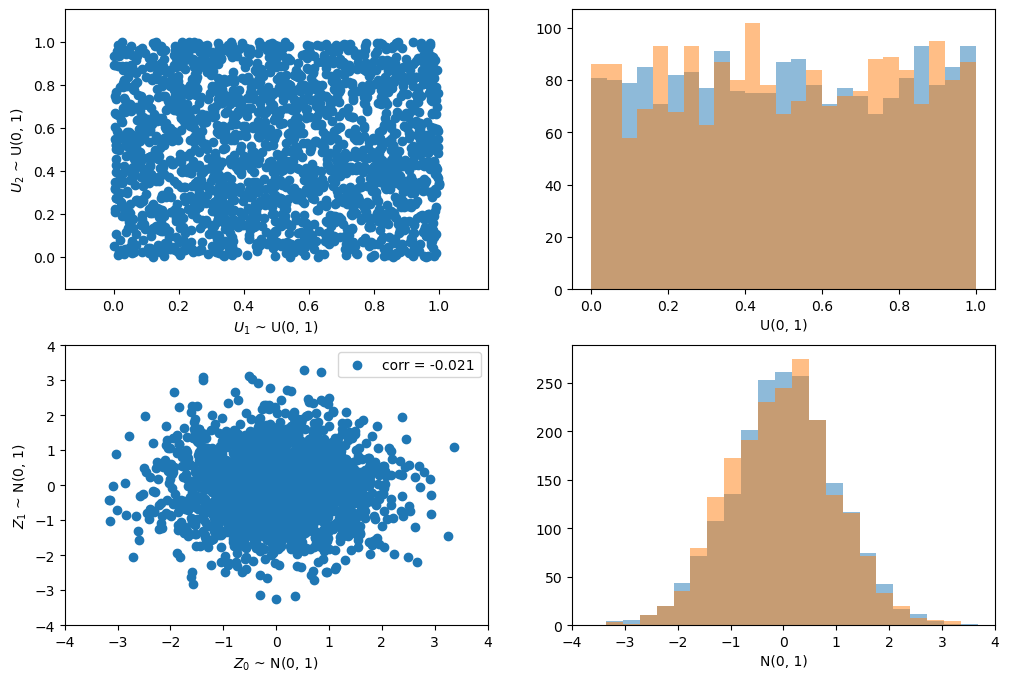

In [30]:
U = np.random.uniform(low=0, high=1, size=(2, 2000))
U1 = U[0, :]
U2 = U[1, :]

Z0 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
Z1 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].scatter(U1, U2)
ax[0, 0].set_xlim(-0.15, 1.15)
ax[0, 0].set_ylim(-0.15, 1.15)
ax[0, 0].set_xlabel(r'$U_1$ ~ U(0, 1)')
ax[0, 0].set_ylabel(r'$U_2$ ~ U(0, 1)')

ax[0, 1].hist(U1, bins=25, range=(0, 1), alpha=0.5)
ax[0, 1].hist(U2, bins=25, range=(0, 1), alpha=0.5)
ax[0, 1].set_xlabel('U(0, 1)')

ax[1, 0].scatter(Z0, Z1, label=f'corr = {round(np.corrcoef(Z0, Z1)[0, 1], 3)}')
ax[1, 0].set_xlim(-4, 4)
ax[1, 0].set_ylim(-4, 4)
ax[1, 0].set_xlabel(r'$Z_0$ ~ N(0, 1)')
ax[1, 0].set_ylabel(r'$Z_1$ ~ N(0, 1)')
ax[1, 0].legend()

ax[1, 1].hist(Z0, bins=25, range=(-4, 4), alpha=0.5)
ax[1, 1].hist(Z1, bins=25, range=(-4, 4), alpha=0.5)
ax[1, 1].set_xlim(-4, 4)
ax[1, 1].set_xlabel('N(0, 1)')
plt.show()